# Reconstrucción de energía de los rayos gamma detectados por HAWC
Por: Josué Cuauhtémoc Bucio Rivera \
El observatorio HAWC (High-Altitude Water Cherenkov) es un instrumento que detecta, entre otras cosas, rayos gamma de muy altas energías. Los rayos gamma, al entrar en contacto con la atmósfera, generan cascadas de partículas que HAWC detecta en sus tanques. Un reto importante al que nos enfrentamos es determinar la energía original a partir de los parámetros que HAWC puede medir; este problema es conocido como reconstrucción de energía.

Al ser un problema relevante, ya existen modelos de reconstrucción estadísticos como GP, o incluso modelos de redes neuronales, como el implementado en [1] (por S. S. Marinelli y J. A. Goodman, ICRC 2017), en el que se utiliza un conjunto de características de la cascada para el entrenamiento.

## Objetivo
El objetivo de este proyecto es desarrollar una red neuronal para la reconstruccion de energia de los rayos gamma detectados por HAWC y comparar el modelo desarrollado con los modelos ya existentes.

Para el desarrollo del proyecto se utilizará un conjunto de datos proporcionado, rico en variables descriptivas de las cascadas [2], con el objetivo de predecir la variable mc.logEnergy, comparando nuestros resultados con los estimadores existentes como rec.logNNEnergy y rec.logGP.

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras import regularizers
from tensorflow.keras.layers import Dense, Dropout
import matplotlib.pyplot as plt
from matplotlib import colors
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import plot_model

In [3]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/_subsample_1000000_subsamples_filtered_selectedcols.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Muestreo de datos. 
Se utilizaron 1,000,000 datos de diferentes caracterísiticas recabados por HAWC de rayos gamma para entrenar a la red neuronal. Los datos de la energía "verdadera" están dados por simulaciones de Monte-Carlo. 

In [4]:
#Caracteristicas sugeridas por el articulo [1]
indices_features = [df.columns.get_loc('rec.zenithAngle'), df.columns.get_loc('rec.coreX'), df.columns.get_loc('rec.coreY'),
          df.columns.get_loc('rec.nHit'), df.columns.get_loc('rec.logNPE'), df.columns.get_loc('rec.logMaxPE'),
          df.columns.get_loc('rec.CxPE40'), df.columns.get_loc('rec.LDFAge'), df.columns.get_loc('rec.PINC'),
          df.columns.get_loc('rec.fAnnulusCharge0'), df.columns.get_loc('rec.fAnnulusCharge1'), df.columns.get_loc('rec.fAnnulusCharge2'),
          df.columns.get_loc('rec.fAnnulusCharge3'), df.columns.get_loc('rec.fAnnulusCharge4'), df.columns.get_loc('rec.fAnnulusCharge5'),
          df.columns.get_loc('rec.fAnnulusCharge6'), df.columns.get_loc('rec.fAnnulusCharge7'), df.columns.get_loc('rec.fAnnulusCharge8')]

indice_prediccion = df.columns.get_loc('mc.logEnergy')
indice_modeloAlterno = df.columns.get_loc('rec.logNNEnergy')
indice_modelo_GP = df.columns.get_loc("rec.logGP")

In [5]:
corr = df.corr()
mask = (corr.abs() > 0.5) & (corr != 1.0)
filtered_corr = corr.where(mask).dropna(how='all').dropna(axis=1, how='all')

In [6]:
print(filtered_corr['mc.logEnergy'])

mc.radiusWeight           0.524339
mc.logEnergy                   NaN
rec.nChAvail                   NaN
rec.nHitTot               0.561095
rec.nHit                  0.560905
rec.nHitSP10                   NaN
rec.nHitSP20              0.501344
rec.nTankAvail                 NaN
rec.nTankHitTot           0.643156
rec.nTankHit              0.637678
rec.windowHits                 NaN
rec.logMaxPE                   NaN
rec.logNPE                     NaN
rec.CxPE40                     NaN
rec.zenithAngle                NaN
rec.azimuthAngle               NaN
rec.coreX                      NaN
rec.coreY                      NaN
rec.coreFiduScale              NaN
rec.planeNDOF             0.516270
rec.planeChi2             0.561797
rec.fAnnulusCharge0            NaN
rec.fAnnulusCharge1            NaN
rec.chargeFiduScale50          NaN
rec.chargeFiduScale70          NaN
rec.chargeFiduScale90          NaN
rec.LDFAge                     NaN
rec.LDFAmp                     NaN
rec.LDFChi2         

In [7]:
#Caracteristicas sugeridas por el articulo [1] mas caracteristicas agregadas por su correlacion
indices_features_corr = [df.columns.get_loc('rec.zenithAngle'), df.columns.get_loc('rec.coreX'), df.columns.get_loc('rec.coreY'),
          df.columns.get_loc('rec.nHit'), df.columns.get_loc('rec.logNPE'), df.columns.get_loc('rec.logMaxPE'),
          df.columns.get_loc('rec.CxPE40'), df.columns.get_loc('rec.LDFAge'), df.columns.get_loc('rec.PINC'),
          df.columns.get_loc('rec.fAnnulusCharge0'), df.columns.get_loc('rec.fAnnulusCharge1'), df.columns.get_loc('rec.fAnnulusCharge2'),
          df.columns.get_loc('rec.fAnnulusCharge3'), df.columns.get_loc('rec.fAnnulusCharge4'), df.columns.get_loc('rec.fAnnulusCharge5'),
          df.columns.get_loc('rec.fAnnulusCharge6'), df.columns.get_loc('rec.fAnnulusCharge7'), df.columns.get_loc('rec.fAnnulusCharge8'),
          df.columns.get_loc('rec.planeChi2'), df.columns.get_loc('rec.planeNDOF'), df.columns.get_loc('rec.nTankHit'),
          df.columns.get_loc('rec.nTankHitTot'), df.columns.get_loc('rec.nHitTot')]

In [8]:
features = df.iloc[:, indices_features].values
cos_zenith_f = np.cos(features[:, 0]).reshape(-1, 1)
features = np.hstack((features, cos_zenith_f ))
features[:, 0] = np.sin(features[:, 0])

features_corr = df.iloc[:, indices_features_corr].values
cos_zenith_fc = np.cos(features_corr[:, 0]).reshape(-1, 1)
features_corr = np.hstack((features_corr, cos_zenith_fc ))
features_corr[:, 0] = np.sin(features_corr[:, 0])

prediccion = df.iloc[:, indice_prediccion].values

In [9]:
#Normalizacion y callbacks
scaler_base = StandardScaler()
scaler_corr = StandardScaler()
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint1 = ModelCheckpoint('mejor_modelo1.h5', monitor='val_loss', save_best_only=True, mode='min')
checkpoint2 = ModelCheckpoint('mejor_modelo2.h5', monitor='val_loss', save_best_only=True, mode='min')
checkpoint3 = ModelCheckpoint('mejor_modelo3.h5', monitor='val_loss', save_best_only=True, mode='min')
checkpoint4 = ModelCheckpoint('mejor_modelo4.h5', monitor='val_loss', save_best_only=True, mode='min')

In [10]:
all_indices = np.arange(len(df))
#Esto nos permitira usar los mismos indices para todos los modelos
train_val_indices, final_test_indices = train_test_split(all_indices, test_size=0.2, random_state=42)

#Los datos de validacion para todos los modelos
final_features_base_test = features[final_test_indices]
final_features_corr_test = features_corr[final_test_indices]
final_target_test = prediccion[final_test_indices]

#Datos a dividir en entrenamiento y validacion para cada modelo
features_corr_train_val = features_corr[train_val_indices]
features_base_train_val = features[train_val_indices]
target_train_val = prediccion[train_val_indices]

#Escalamiento de los features para los modelos sin correlacionar
features_base_train_val_scaled = scaler_base.fit_transform(features_base_train_val)
final_features_base_test_scaled = scaler_base.transform(final_features_base_test)

#Particiones de los modelos sin correlacionar
x_train_base, x_val_base, y_train_base, y_val_base = train_test_split(
    features_base_train_val_scaled, target_train_val, test_size=0.125, random_state=42)

#Escalamiento de los features correlacionados
features_corr_train_val_scaled = scaler_corr.fit_transform(features_corr_train_val)
final_features_corr_test_scaled = scaler_corr.transform(final_features_corr_test)

#Particion del modelo correlacionado
x_train_corr, x_val_corr, y_train_corr, y_val_corr = train_test_split(
    features_corr_train_val_scaled, target_train_val, test_size=0.125, random_state=42)

In [11]:
#Separacion datos de entremiento y prueba
longitud = len(x_train_corr)

# Proceso de la definición de la topología de la red.
Durante el proceso de construcción se intentó lo siguiente: \
-Aumentar el número de neuronas en las capas ocultas o el número de capas ocultas; se encontró que después de alrededor de 128 neuronas y 3 capas ocultas el redimiento no mejora, debajo de estos valores el rendimiento si empeora. \
-Uso de dropouts; el uso de dropouts para este problema fue innecesario ya que como se observará en los esquemas el rendimiento permance igual e incluso empeora, en el modelo final no fue implementado.\
-Uso de optimizadores; en este caso se intentó con SGD, RMSprop, adagrad, adadelta, nadam y adam, solo los últimos dos mejoraban el rendimiento en espcial adam, por eso fue empleado en el último modelo. \
-Uso de regularizadores; se intentó mejorar el rendimiento con L1 y L2 y combinaciones de ellos al final se encontró que el uso de L2 en la segunda capa oculta mejoraba el rendimiento y se implementó para el modelo final. 
# Callbacks.
Aquí fueron de suma importancia los callbacks, con especial mención para 'EarlyStopping', ya que los archivos eran muy pesados no se podía correr muchas veces. Se solventó con el uso de 'EarlyStopping'. Por otro lado, también se usó 'ModelCheckpoint', pero como se observa en las gráficas, los últimos modelos —que son los mejores— son muy similares entre sí; su uso no es fundamental.


# Modelo 1

In [12]:
model_1 = Sequential([
Dense(64, activation='relu', input_shape=(19,)),
Dense(64, activation='relu'),
Dense(1)])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model_1.compile(loss='mean_squared_error', metrics=['mae'])

In [14]:
history_1 = model_1.fit(x_train_base, y_train_base,
                    epochs=200,
                    batch_size=512,
                    validation_data=(x_val_base, y_val_base),
                    callbacks=[early_stop, checkpoint1])

Epoch 1/200
1359/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7901 - mae: 0.5635

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.7866 - mae: 0.5622 - val_loss: 0.1924 - val_mae: 0.3224
Epoch 2/200
1362/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1687 - mae: 0.2982

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - loss: 0.1686 - mae: 0.2982 - val_loss: 0.1551 - val_mae: 0.2848
Epoch 3/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.1567 - mae: 0.2869 - val_loss: 0.1561 - val_mae: 0.2846
Epoch 4/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.1504 - mae: 0.2812 - val_loss: 0.1674 - val_mae: 0.2969
Epoch 5/200
1362/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1465 - mae: 0.2779

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.1465 - mae: 0.2779 - val_loss: 0.1481 - val_mae: 0.2776
Epoch 6/200
1361/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1446 - mae: 0.2757

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.1446 - mae: 0.2757 - val_loss: 0.1437 - val_mae: 0.2730
Epoch 7/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.1427 - mae: 0.2737 - val_loss: 0.1455 - val_mae: 0.2759
Epoch 8/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.1409 - mae: 0.2721 - val_loss: 0.1498 - val_mae: 0.2841
Epoch 9/200
1364/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1400 - mae: 0.2714

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.1399 - mae: 0.2714 - val_loss: 0.1433 - val_mae: 0.2727
Epoch 10/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.1388 - mae: 0.2702 - val_loss: 0.1455 - val_mae: 0.2808
Epoch 11/200
1361/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1382 - mae: 0.2695

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.1382 - mae: 0.2695 - val_loss: 0.1416 - val_mae: 0.2737
Epoch 12/200
1361/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1373 - mae: 0.2681

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.1373 - mae: 0.2681 - val_loss: 0.1385 - val_mae: 0.2704
Epoch 13/200
1358/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1363 - mae: 0.2677

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.1363 - mae: 0.2677 - val_loss: 0.1378 - val_mae: 0.2687
Epoch 14/200
1367/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1362 - mae: 0.2669

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.1362 - mae: 0.2669 - val_loss: 0.1368 - val_mae: 0.2655
Epoch 15/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.1351 - mae: 0.2662 - val_loss: 0.1442 - val_mae: 0.2787
Epoch 16/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.1336 - mae: 0.2649 - val_loss: 0.1402 - val_mae: 0.2683
Epoch 17/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.1343 - mae: 0.2652 - val_loss: 0.1441 - val_mae: 0.2730
Epoch 18/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.1341 - mae: 0.2650 - val_loss: 0.1503 - val_mae: 0.2812
Epoch 19/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 0.1338 - mae: 0.2647 - val_loss: 0.1417 - val_mae: 0.2694


In [15]:
model_1 = load_model('mejor_modelo1.h5')

# Modelo 2

In [16]:
model_2 = Sequential([
Dense(128, activation='relu', input_shape=(19,)),
Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
Dense(128, activation='tanh'),
Dense(1)])

In [17]:
model_2.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

In [18]:
history_2 = model_2.fit(x_train_base, y_train_base,
                    epochs=200,
                    batch_size=512,
                    validation_data=(x_val_base, y_val_base),
                    callbacks=[early_stop, checkpoint2])

Epoch 1/200
1365/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.2220 - mae: 0.4747

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 1.2200 - mae: 0.4743 - val_loss: 0.1716 - val_mae: 0.2849
Epoch 2/200
1361/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1627 - mae: 0.2829

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 0.1627 - mae: 0.2829 - val_loss: 0.1526 - val_mae: 0.2788
Epoch 3/200
1362/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1496 - mae: 0.2757

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 0.1496 - mae: 0.2757 - val_loss: 0.1516 - val_mae: 0.2836
Epoch 4/200
1367/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1445 - mae: 0.2717

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 0.1445 - mae: 0.2717 - val_loss: 0.1433 - val_mae: 0.2713
Epoch 5/200
1367/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1426 - mae: 0.2700

...

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 0.1383 - mae: 0.2664 - val_loss: 0.1386 - val_mae: 0.2652
Epoch 11/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - loss: 0.1370 - mae: 0.2648 - val_loss: 0.1420 - val_mae: 0.2687
Epoch 12/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 0.1368 - mae: 0.2650 - val_loss: 0.1423 - val_mae: 0.2747
Epoch 13/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1360 - mae: 0.2647

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.1360 - mae: 0.2647 - val_loss: 0.1372 - val_mae: 0.2629
Epoch 14/200
1367/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1364 - mae: 0.2645

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 0.1364 - mae: 0.2645 - val_loss: 0.1368 - val_mae: 0.2652
Epoch 15/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 0.1356 - mae: 0.2642 - val_loss: 0.1369 - val_mae: 0.2636
Epoch 16/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 0.1355 - mae: 0.2639 - val_loss: 0.1369 - val_mae: 0.2639
Epoch 17/200
1367/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1355 - mae: 0.2640

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 0.1355 - mae: 0.2640 - val_loss: 0.1353 - val_mae: 0.2631
Epoch 18/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 0.1344 - mae: 0.2631 - val_loss: 0.1368 - val_mae: 0.2635
Epoch 19/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 0.1347 - mae: 0.2633 - val_loss: 0.1366 - val_mae: 0.2647
Epoch 20/200
1367/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1348 - mae: 0.2634

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 0.1348 - mae: 0.2634 - val_loss: 0.1346 - val_mae: 0.2625
Epoch 21/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 0.1343 - mae: 0.2629 - val_loss: 0.1370 - val_mae: 0.2638
Epoch 22/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.1343 - mae: 0.2630 - val_loss: 0.1347 - val_mae: 0.2620
Epoch 23/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.1340 - mae: 0.2625 - val_loss: 0.1386 - val_mae: 0.2652
Epoch 24/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 0.1343 - mae: 0.2626 - val_loss: 0.1355 - val_mae: 0.2641
Epoch 25/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 0.1337 - mae: 0.2622 - val_loss: 0.1365 - val_mae: 0.2634


In [19]:
model_2 = load_model('mejor_modelo2.h5')

# Modelo 3

In [20]:
model_3 = Sequential([
Dense(128, activation='relu', input_shape=(19,)),
Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
Dropout(0.5),
Dense(128, activation='tanh'),
Dense(1)])

In [21]:
model_3.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

In [22]:
history_3 = model_3.fit(x_train_base, y_train_base,
                    epochs=200,
                    batch_size=512,
                    validation_data=(x_val_base, y_val_base),
                    callbacks=[early_stop, checkpoint3])

Epoch 1/200
1365/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.1336 - mae: 0.4977

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 1.1317 - mae: 0.4973 - val_loss: 0.1750 - val_mae: 0.2867
Epoch 2/200
1367/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1825 - mae: 0.3021

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 0.1825 - mae: 0.3021 - val_loss: 0.1627 - val_mae: 0.2823
Epoch 3/200
1366/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1695 - mae: 0.2929

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 24s 11ms/step - loss: 0.1695 - mae: 0.2929 - val_loss: 0.1585 - val_mae: 0.2786
Epoch 4/200
1366/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1634 - mae: 0.2884

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 0.1634 - mae: 0.2884 - val_loss: 0.1539 - val_mae: 0.2767
Epoch 5/200
1366/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1593 - mae: 0.2850

...

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 0.1464 - mae: 0.2730 - val_loss: 0.1428 - val_mae: 0.2656
Epoch 15/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 0.1457 - mae: 0.2719 - val_loss: 0.1436 - val_mae: 0.2688
Epoch 16/200
1365/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1460 - mae: 0.2723

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 0.1460 - mae: 0.2723 - val_loss: 0.1419 - val_mae: 0.2666
Epoch 17/200
1362/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1459 - mae: 0.2724

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 0.1459 - mae: 0.2724 - val_loss: 0.1418 - val_mae: 0.2657
Epoch 18/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 0.1452 - mae: 0.2717 - val_loss: 0.1452 - val_mae: 0.2687
Epoch 19/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 0.1448 - mae: 0.2714 - val_loss: 0.1428 - val_mae: 0.2679
Epoch 20/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 0.1445 - mae: 0.2713 - val_loss: 0.1477 - val_mae: 0.2715
Epoch 21/200
1362/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1454 - mae: 0.2715

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 0.1454 - mae: 0.2715 - val_loss: 0.1413 - val_mae: 0.2647
Epoch 22/200
1367/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1452 - mae: 0.2715

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 0.1452 - mae: 0.2715 - val_loss: 0.1411 - val_mae: 0.2652
Epoch 23/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 0.1449 - mae: 0.2712 - val_loss: 0.1463 - val_mae: 0.2734
Epoch 24/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 0.1448 - mae: 0.2713 - val_loss: 0.1416 - val_mae: 0.2649
Epoch 25/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - loss: 0.1442 - mae: 0.2705 - val_loss: 0.1418 - val_mae: 0.2664
Epoch 26/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 0.1441 - mae: 0.2706 - val_loss: 0.1417 - val_mae: 0.2664
Epoch 27/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 0.1441 - mae: 0.2704 - val_loss: 0.1417 - val_mae: 0.2663


In [23]:
model_3 = load_model('mejor_modelo3.h5')

# Modelo 2 con datos de entramiento agregados por alta correlación (Modelo 2 corr)

In [24]:
model_2_corr = Sequential([
Dense(128, activation='relu', input_shape=(24,)),
Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
Dense(128, activation='tanh'),
Dense(1)])

In [25]:
model_2_corr.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

In [26]:
history_2_corr = model_2_corr.fit(x_train_corr, y_train_corr,
                    epochs=200,
                    batch_size=512,
                    validation_data=(x_val_corr, y_val_corr),
                    callbacks=[early_stop, checkpoint4])

Epoch 1/200
1361/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.9675 - mae: 0.4037

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 0.9644 - mae: 0.4031 - val_loss: 0.1317 - val_mae: 0.2567
Epoch 2/200
1359/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1246 - mae: 0.2526

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 0.1245 - mae: 0.2526 - val_loss: 0.1144 - val_mae: 0.2419
Epoch 3/200
1365/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1137 - mae: 0.2444

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 0.1137 - mae: 0.2444 - val_loss: 0.1097 - val_mae: 0.2403
Epoch 4/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 0.1088 - mae: 0.2395 - val_loss: 0.1113 - val_mae: 0.2454
Epoch 5/200
1359/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1067 - mae: 0.2375

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 0.1067 - mae: 0.2375 - val_loss: 0.1080 - val_mae: 0.2404
Epoch 6/200
1360/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1055 - mae: 0.2361

...

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 0.1028 - mae: 0.2332 - val_loss: 0.1015 - val_mae: 0.2322
Epoch 11/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 0.1023 - mae: 0.2326 - val_loss: 0.1031 - val_mae: 0.2300
Epoch 12/200
1364/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1023 - mae: 0.2324

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 0.1023 - mae: 0.2324 - val_loss: 0.1010 - val_mae: 0.2306
Epoch 13/200
1362/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1010 - mae: 0.2311

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 0.1010 - mae: 0.2311 - val_loss: 0.1005 - val_mae: 0.2307
Epoch 14/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 0.1014 - mae: 0.2316 - val_loss: 0.1019 - val_mae: 0.2292
Epoch 15/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 0.1007 - mae: 0.2311 - val_loss: 0.1016 - val_mae: 0.2314
Epoch 16/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 0.1006 - mae: 0.2308 - val_loss: 0.1040 - val_mae: 0.2367
Epoch 17/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.1006 - mae: 0.2308 - val_loss: 0.1026 - val_mae: 0.2315
Epoch 18/200
1363/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1007 - mae: 0.2310

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 0.1007 - mae: 0.2310 - val_loss: 0.1004 - val_mae: 0.2313
Epoch 19/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 0.0999 - mae: 0.2301 - val_loss: 0.1010 - val_mae: 0.2287
Epoch 20/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.0999 - mae: 0.2301 - val_loss: 0.1020 - val_mae: 0.2294
Epoch 21/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0999 - mae: 0.2299

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - loss: 0.0999 - mae: 0.2299 - val_loss: 0.0985 - val_mae: 0.2270
Epoch 22/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 0.0993 - mae: 0.2295 - val_loss: 0.0998 - val_mae: 0.2297
Epoch 23/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 0.0997 - mae: 0.2300 - val_loss: 0.1003 - val_mae: 0.2319
Epoch 24/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 0.0996 - mae: 0.2299 - val_loss: 0.0991 - val_mae: 0.2278
Epoch 25/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 0.0992 - mae: 0.2293 - val_loss: 0.0995 - val_mae: 0.2294
Epoch 26/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 0.0993 - mae: 0.2293 - val_loss: 0.1002 - val_mae: 0.2270


In [27]:
model_2_corr = load_model('mejor_modelo4.h5')

In [28]:
history_dict = history_1.history
history_dict.keys()

dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])

<ipython-input-30-e972ebddce24>:14: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo" (-> color='b'). The keyword argument will take precedence.
  axis[a, b].plot(epochs, loss_values, "bo", label="Training loss", c='r')


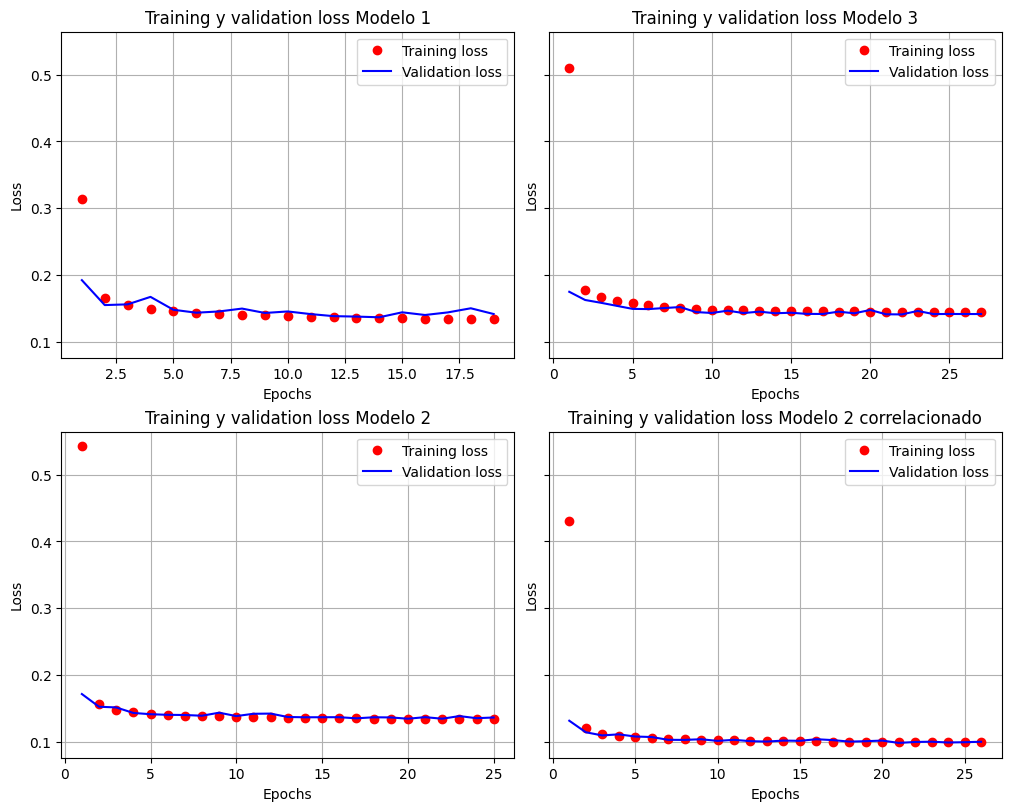

In [30]:
history_dicts = [history_1.history, history_2.history, history_3.history, history_2_corr.history]
nombres = ['Modelo 1', 'Modelo 2', 'Modelo 3', 'Modelo 2 correlacionado' ]

fig, axis = plt.subplots(2, 2, figsize=(10,8), sharey='all', constrained_layout=1)
a, b = 0, 0
for i in range(len(history_dicts)):
  if a == 2 : a = 0; b = 1

  history_dict, nombre = history_dicts[i], nombres[i]
  loss_values = history_dict["loss"]
  val_loss_values = history_dict["val_loss"]
  epochs = range(1, len(loss_values) + 1)

  axis[a, b].plot(epochs, loss_values, "bo", label="Training loss", c='r')
  axis[a, b].plot(epochs, val_loss_values, "b", label="Validation loss")
  axis[a, b].set_title("Training y validation loss " + nombre)
  axis[a, b].set_xlabel("Epochs")
  axis[a, b].set_ylabel("Loss")
  axis[a, b].legend()
  axis[a, b].grid(True)

  a += 1
plt.show()

<ipython-input-31-dfae4b62ef23>:13: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo" (-> color='b'). The keyword argument will take precedence.
  axis[a, b].plot(epochs, loss_values, "bo", label="Training mae", c='r')


<Figure size 640x480 with 0 Axes>

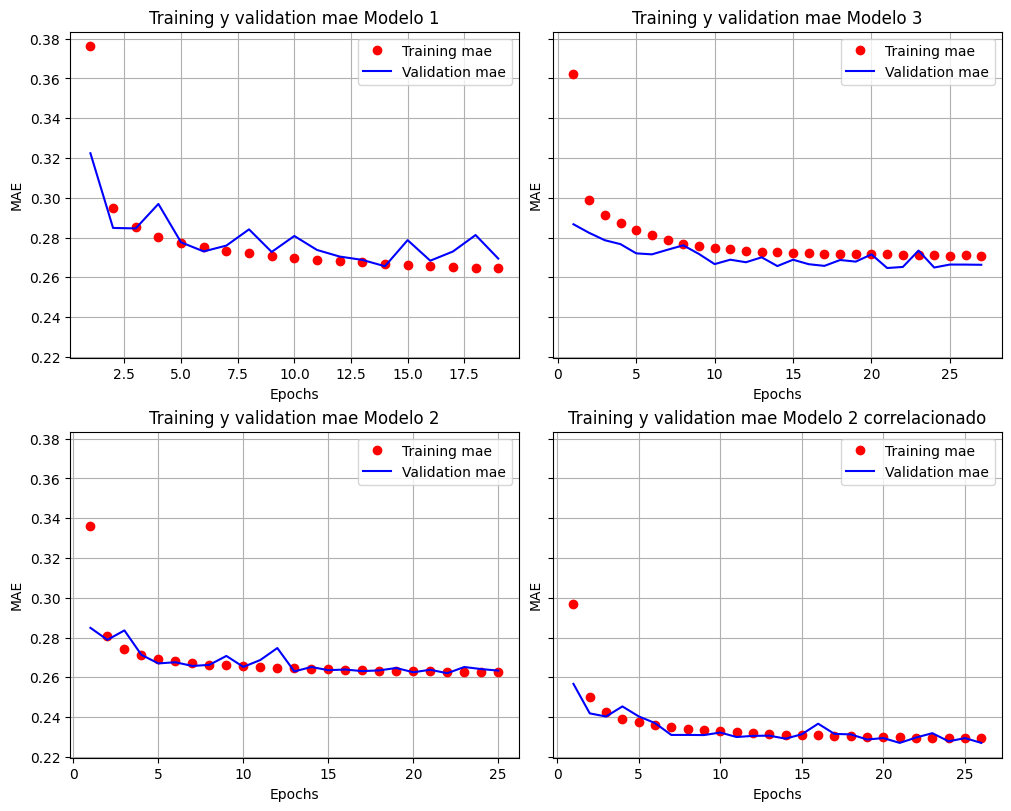

In [31]:
plt.clf()

fig, axis = plt.subplots(2, 2, figsize=(10,8), sharey='all', constrained_layout=1)
a, b = 0, 0
for i in range(len(history_dicts)):
  if a == 2 : a = 0; b = 1

  history_dict, nombre = history_dicts[i], nombres[i]
  loss_values = history_dict["mae"]
  val_loss_values = history_dict["val_mae"]
  epochs = range(1, len(loss_values) + 1)

  axis[a, b].plot(epochs, loss_values, "bo", label="Training mae", c='r')
  axis[a, b].plot(epochs, val_loss_values, "b", label="Validation mae")
  axis[a, b].set_title("Training y validation mae " + nombre)
  axis[a, b].set_xlabel("Epochs")
  axis[a, b].set_ylabel("MAE")
  axis[a, b].legend()
  axis[a, b].grid(True)

  a += 1
plt.show()

# Learning rates.

En las gráficas se observa que alrededor de las primeras 10 épocas se tiene un learning rate alto, después de estas épocas se tiene un learning rate normal, parece ser lineal.

In [32]:
modelos = [[model_1, final_features_base_test_scaled, 'Modelo 1'], [model_2, final_features_base_test_scaled, 'Modelo 2'],
           [model_3, final_features_base_test_scaled, 'Modelo 3'], [model_2_corr, final_features_corr_test_scaled, 'Modelo 2 Correlacionado']]

for modelo in modelos :
  model, test, nombre = modelo[0], modelo[1], modelo[2]
  y_pred_full_scaled = model.predict(test).flatten()
  values_array_full = final_target_test
  output_dir = '/content/drive/MyDrive'

  # Ensure shapes match for plotting
  if values_array_full.shape == y_pred_full_scaled.shape:
    number_of_bins = 55
    counts, xedges, yedges = np.histogram2d(values_array_full, y_pred_full_scaled, bins=number_of_bins)
    counts_mean = np.mean(counts)
    counts_std = np.std(counts)
    print(f"  2D Histogram Mean: {counts_mean:.4f}")
    print(f"  2D Histogram Standard Deviation: {counts_std:.4f}")

    plt.figure(figsize=(12, 10))
    plt.pcolormesh(xedges, yedges, counts.T, cmap='rainbow', norm=colors.LogNorm())
    min_val = min(np.min(values_array_full), np.min(y_pred_full_scaled))
    max_val = max(np.max(values_array_full), np.max(y_pred_full_scaled))
    plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--') # Line y=x

    plt.xlabel(r'$\log(E_{\mathrm{True}}/GeV)$', fontsize=15)
    plt.ylabel(r'$\log(E_{\mathrm{reco}}/GeV)$', fontsize=15)

    plt.xlim(min(2.5, min_val - 0.1), max(6.5, max_val + 0.1))
    plt.ylim(min(2.5, min_val - 0.1), max(6.5, max_val + 0.1))
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.colorbar(label='Counts')
    plt.title(f'True vs Predicted Energy (Full Filtered Dataset) {nombre}')
    # Save plot directly in output_dir
    plot2d_path = f'{output_dir}/plot_MLP_validation_2Dhist{nombre}.png'
    plt.savefig(plot2d_path, bbox_inches='tight')
    print(f"2D histogram plot saved to {plot2d_path}")
    plt.close()
  else:
    print("Skipping 2D histogram plot.")

6250/6250 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
  2D Histogram Mean: 66.1157
  2D Histogram Standard Deviation: 218.1469
2D histogram plot saved to /content/drive/MyDrive/plot_MLP_validation_2DhistModelo 1.png
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
  2D Histogram Mean: 66.1157
  2D Histogram Standard Deviation: 190.7174
2D histogram plot saved to /content/drive/MyDrive/plot_MLP_validation_2DhistModelo 2.png
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step
  2D Histogram Mean: 66.1157
  2D Histogram Standard Deviation: 164.6809
2D histogram plot saved to /content/drive/MyDrive/plot_MLP_validation_2DhistModelo 3.png
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step
  2D Histogram Mean: 66.1157
  2D Histogram Standard Deviation: 210.2728
2D histogram plot saved to /content/drive/MyDrive/plot_MLP_validation_2DhistModelo 2 Correlacionado.png


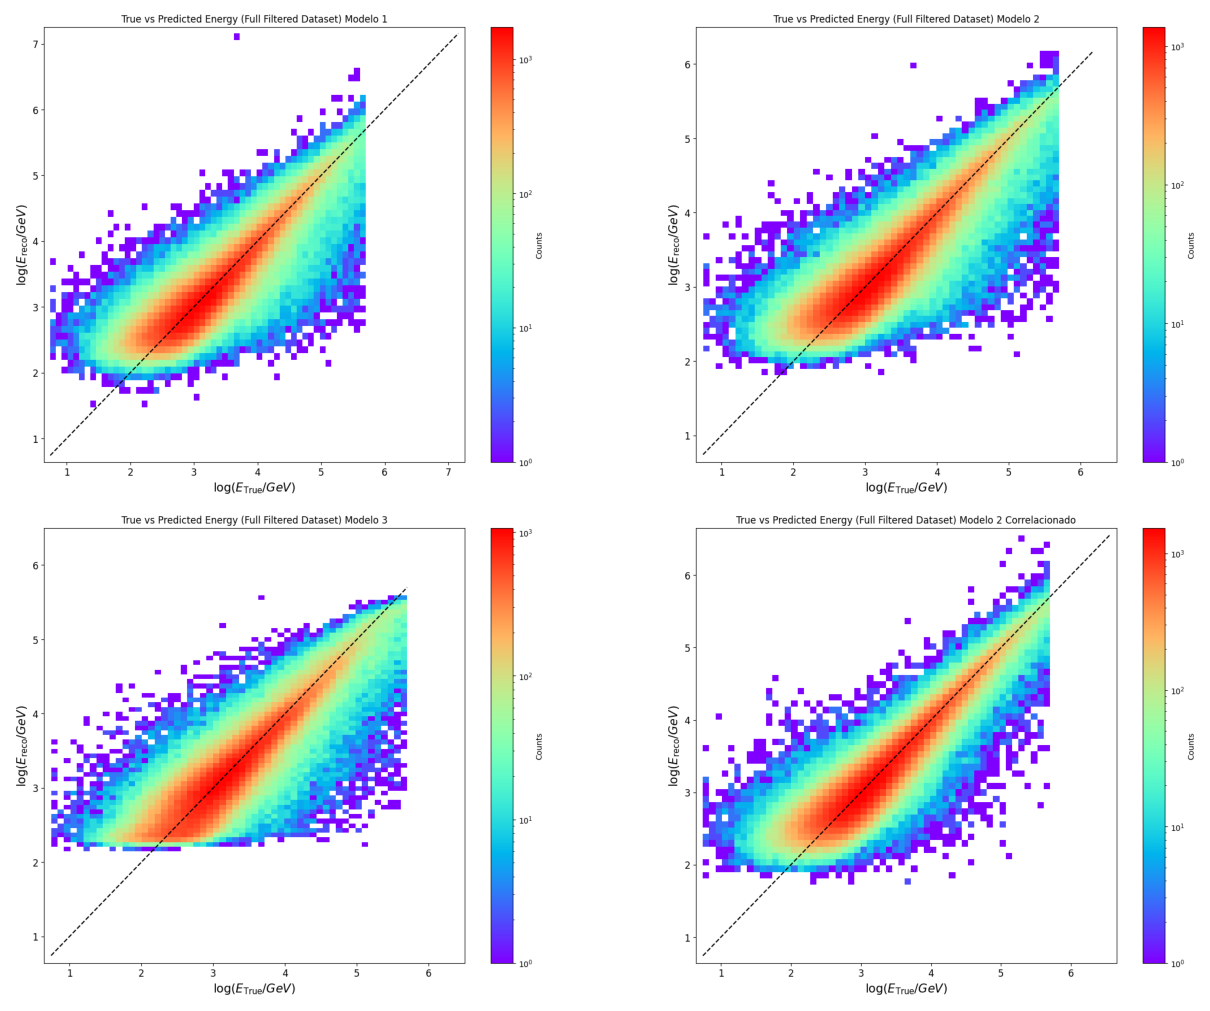

In [33]:
fig, axis = plt.subplots(2, 2, figsize=(13,10), sharey='all', constrained_layout=1)
contador = 0
for i in range(0,2):
  for j in range(0,2):
    nombre = modelos[contador][2]
    contador += 1
    im = plt.imread(f'/content/drive/MyDrive/plot_MLP_validation_2Dhist{nombre}.png')
    img = axis[i,j].imshow(im)
    axis[i,j].set_axis_off()
plt.show()

In [34]:
energy_bins = np.array([0.6, 2.5, 2.75, 3.0, 3.25, 3.5, 3.75, 4.0, 4.25, 4.5, 4.75, 5.0, 5.25, 5.5, np.inf])
bin_centers = ( energy_bins [: -1] + energy_bins [1:]) / 2.0

In [35]:
from scipy.optimize import curve_fit
from scipy.stats import norm

In [36]:
def gauss_func_scipy(x , a , mu , sigma ):
  return a*np.exp(-(x-mu)**2/(2*sigma**2) )

In [37]:
def fit_gaussian_to_errors(error_data_for_bin , hist_bins =50):
  if error_data_for_bin is None or len ( error_data_for_bin ) < 20:
    return np.nan, np.nan

  counts, bin_edges = np.histogram(error_data_for_bin, bins = hist_bins, density = False )
  bin_centers_hist = (bin_edges[: -1] + bin_edges[1:])/2.0

  non_zero_indices = counts > 0
  if not np.any(non_zero_indices):
    return np.nan, np.nan

  counts_fit = counts[non_zero_indices]
  bin_centers_fit = bin_centers_hist[non_zero_indices]

  try:
    initial_amplitude = np.max(counts_fit)
    initial_mu = np.mean(error_data_for_bin)
    initial_sigma = np.std(error_data_for_bin)

    if initial_sigma == 0 :
      initial_sigma = 1e-2

    popt , pcov = curve_fit(gauss_func_scipy , bin_centers_fit, counts_fit, p0=[ initial_amplitude , initial_mu, initial_sigma ], maxfev =10000)

    mu_fit = popt[1]
    sigma_fit = abs(popt[2])
    return mu_fit, sigma_fit

  except RuntimeError:
    valid_data = error_data_for_bin [~np.isnan(error_data_for_bin) & ~np.isinf( error_data_for_bin )]
    if len ( valid_data ) > 1:
      return np.mean(valid_data), np.std(valid_data)
    else:
      return np.nan, np.nan


In [38]:
def grafi(modelo, test):
  global final_target_test
  energia_simulacion = final_target_test
  #Comparacion de modelos
  try :
    energia_modelo = modelo.predict(test)
    energia_modelo = energia_modelo.flatten()
  except AttributeError:
    energia_modelo = modelo

  errors_all = energia_modelo - energia_simulacion
  errors_per_bin = []
  events_in_bin_counts = []

  for i in range (len(energy_bins) - 1) :
    low_e = energy_bins[i]
    high_e = energy_bins[i + 1]

    # Mascara para seleccionar eventos en el bin actual
    mask = ( energia_simulacion >= low_e ) & ( energia_simulacion < high_e )

    errors_in_this_bin = errors_all[mask]
    errors_per_bin.append(errors_in_this_bin)
    events_in_bin_counts.append(len( errors_in_this_bin ) )

    #print(f"Bin [{ low_e :.2f} , { high_e :.2f}): { len ( errors_in_this_bin )} eventos ]")

  bias_values = []
  resolution_values = []
  bin_centers_plot = []

  for i in range(len(energy_bins) -1):
    errors_in_this_bin = errors_per_bin[i]
    mu, sigma = fit_gaussian_to_errors(errors_in_this_bin)

    if not ( np.isnan(mu) or np.isnan(sigma)):
      bias_values.append(mu)
      resolution_values.append(sigma)
      bin_centers_plot.append(bin_centers[i])
  return bias_values, resolution_values, bin_centers_plot

In [39]:
energia_modelo_nn = df.iloc[final_test_indices, indice_modeloAlterno].values
energia_modelo_gp = df.iloc[final_test_indices, indice_modelo_GP].values

In [42]:
modelos = [[model_1, final_features_base_test_scaled, 'Modelo 1'], [model_2, final_features_base_test_scaled, 'Modelo 2'],
           [model_3, final_features_base_test_scaled, 'Modelo 3'], [model_2_corr, final_features_corr_test_scaled, 'Modelo 2 Correlacionado'],
           [energia_modelo_nn, None, 'Modelo NN'], [energia_modelo_gp, None, 'Modelo GP']]
bias_values_all = []
resolution_values_all = []
bin_centers_plot_all = []

for modelo in modelos:
  a = grafi(modelo[0], modelo[1])
  bias_values_all.append(a[0])
  resolution_values_all.append(a[1])
  bin_centers_plot_all.append(a[2])

6250/6250 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step


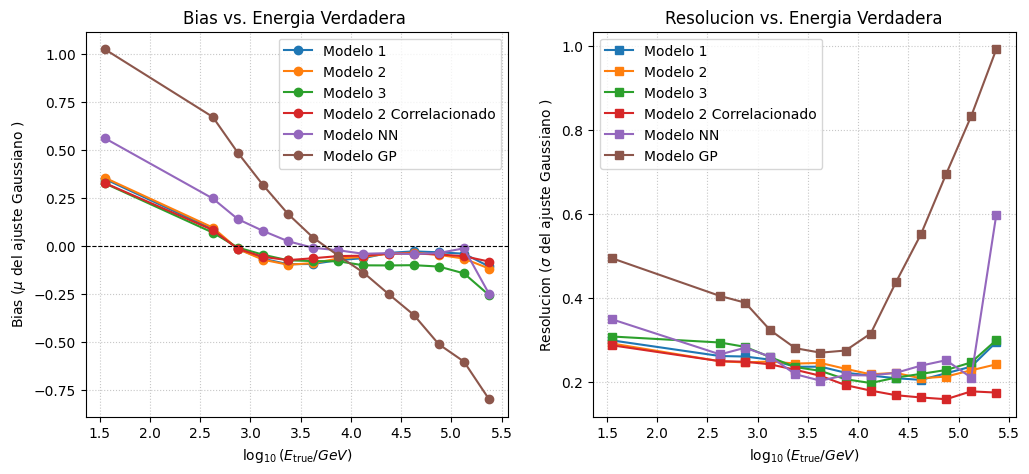

In [43]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
for i in range(0, len(bias_values_all)):
  bias_values = bias_values_all[i]
  bin_centers_plot = bin_centers_plot_all[i]
  plt.plot(bin_centers_plot , bias_values, 'o-' , label=modelos[i][2])

plt.axhline(0, color ='black', linestyle ='--', linewidth =0.8)
plt.xlabel(r'$\log_{10}( E_{\mathrm{true}}/ GeV )$')
plt.ylabel('Bias ($\mu$ del ajuste Gaussiano )')
plt.title('Bias vs. Energia Verdadera ')
plt.grid(True , linestyle =':', alpha =0.7)
plt.legend()

plt.subplot(1, 2, 2)
for i in range(0, len(resolution_values_all)):
  resolution_values = resolution_values_all[i]
  bin_centers_plot = bin_centers_plot_all[i]
  plt.plot(bin_centers_plot , resolution_values, 's-', label =modelos[i][2])

plt.xlabel(r'$\log_{10}( E_{\mathrm{true}}/ GeV )$')
plt.ylabel('Resolucion ($\sigma$ del ajuste Gaussiano )')
plt.title('Resolucion vs. Energia Verdadera')
plt.grid( True , linestyle =':', alpha =0.7)
plt.legend()

plt.show()

### Bias (Sesgo): 
Indica una desviación sistemática promedio de la energía reconstruida respecto a la verdadera. Un bias positivo significa que, en promedio, el algoritmo sobreestima la energía, mientras que un bias negativo indica una subestimación. Idealmente, el bias debería ser cero en todo el rango de energías.
### Resolución de Energía:
Mide la dispersión o el ancho de la distribución de las energías reconstruidas alrededor de la energía verdadera (o del error de reconstrucción alrededor de cero). Una mejor resolución implica una distribución más estrecha, lo que significa menos incertidumbre en la energía reconstruida.

# Uso de transfer learning.

La red no es muy compleja, por lo que no se necesita de una preentrenada.

# Uso de data augmentation.

La cantidad de datos fue suficiente. La diferencia entre el rendimiento de la red entrenada con 500 mil y 1 millón no fue significativa, aunque he de mencionar que había 20.5 millones de datos disponibles, pero por limitaciones computacionales y de red no se pudieron usar.


# Discusión y conclusiones

El modelo construido es mejor a más bajas energías (hasta alrededor de 1000 GeV) y equiparable a altas energías.
Aunque parece ser mejor a las más altas energías (100 000 GeV), la verdad es que el modelo NN mejora mucho aquí con más datos.
No parece que un modelo más robusto sea la solución para mejorar el modelo propuesto aquí en altas energías, sino la cantidad de datos en estas energías. Como se observa en las gráficas, con la cantidad de datos suficientes —como a más bajas energías— el modelo es mejor.

El modelo solo se llegó a entrenar con, a lo más, 5 millones de datos (en la presentación se usó 1 millón). Con esta cantidad de datos, NN sigue siendo mejor en cierta región de altas energías, pero se cree que con la cantidad de datos suficiente el modelo puede superar a NN en todos los rangos de energía.

# Gracias por su atención !

Referencias: \
[1] Marinelli, S. S., & Goodman, J. A. (2017). Measuring High-Energy Spectra with HAWC. Presented on behalf of the HAWC Collaboration. Michigan State University & University of Maryland \
[2] Mirón Enríquez, P. E. (2025). Análisis introductorio del estimador de energía rec.logNNEnergy de HAWC (Documentación de proyecto). Basado en S. S. Marinelli, J. A. Goodman, ICRC 2017, y otros. \
[3] Malone, K.A. (2018) A Survey of the Highest-Energy Astrophysical Sources with the HAWC Observatory. PhD Thesis. Penn State U., Penn State U.